In [2]:
from datetime import datetime
import requests

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import yfinance as yf
import pygad

# Toy example

In [5]:
prices = dict()
prices['A'] = np.array([1,0.5,1,1.5] * 20)
prices['B'] = np.ones_like(prices['A'])
print(prices)

{'A': array([1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. ,
       0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5,
       1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. ,
       1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5,
       1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. ,
       0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5,
       1. , 1.5]), 'B': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])}


In [7]:
returns = np.array([p[1:] / p[:-1] for s, p in prices.items()]).T
w = np.ones(2) / 2
np.cumprod(returns @ w)

array([ 0.75      ,  1.125     ,  1.40625   ,  1.171875  ,  0.87890625,
        1.31835938,  1.64794922,  1.37329102,  1.02996826,  1.54495239,
        1.93119049,  1.60932541,  1.20699406,  1.81049109,  2.26311386,
        1.88592821,  1.41444616,  2.12166924,  2.65208655,  2.21007213,
        1.65755409,  2.48633114,  3.10791393,  2.58992827,  1.9424462 ,
        2.91366931,  3.64208663,  3.03507219,  2.27630415,  3.41445622,
        4.26807027,  3.55672523,  2.66754392,  4.00131588,  5.00164485,
        4.16803738,  3.12602803,  4.68904205,  5.86130256,  4.8844188 ,
        3.6633141 ,  5.49497115,  6.86871394,  5.72392828,  4.29294621,
        6.43941932,  8.04927414,  6.70772845,  5.03079634,  7.54619451,
        9.43274314,  7.86061928,  5.89546446,  8.84319669, 11.05399586,
        9.21166322,  6.90874742, 10.36312112, 12.9539014 , 10.79491784,
        8.09618838, 12.14428257, 15.18035321, 12.65029434,  9.48772075,
       14.23158113, 17.78947641, 14.82456368, 11.11842276, 16.67

# Real stock data

In [29]:
start_date = '2010-01-01'
end_date = '2025-12-31'

In [39]:
sp_ticker = '^GSPC'

sp_data = yf.download(sp_ticker, start=start_date, end=end_date)['Close']
sp_daily_pct = sp_data.pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


In [20]:
def get_sp500_tickers_by_date(target_date_str):
    target_date = pd.to_datetime(target_date_str)
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    
    # Standard headers are usually fine; Wikipedia just wants a non-empty User-Agent
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    
    # 1. Get Tables
    tables = pd.read_html(response.text)
    df_current = tables[0]
    df_changes = tables[1]

    # 2. FLATTEN HEADERS
    # This turns ('Added', 'Ticker') into just 'Added_Ticker'
    df_changes.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_changes.columns]
    
    # 3. Clean Date Column
    # The header usually becomes 'Date_Date' or 'Date_nan' after flattening
    date_col = [c for c in df_changes.columns if 'Date' in c][0]
    df_changes['Clean_Date'] = pd.to_datetime(df_changes[date_col], errors='coerce')

    current_tickers = set(df_current['Symbol'].tolist())

    # 4. Reverse Changes (Working backwards from today)
    relevant_changes = df_changes[df_changes['Clean_Date'] > target_date]

    for _, row in relevant_changes.iterrows():
        # Adjust these strings based on what the flattened headers actually are
        added = row.get('Added_Ticker')
        removed = row.get('Removed_Ticker')

        if pd.notna(added) and added in current_tickers:
            current_tickers.remove(added)
        if pd.notna(removed):
            current_tickers.add(removed)

    return sorted(list(current_tickers))
    
tickers = get_sp500_tickers_by_date(end_train_date)

In [103]:
end_train_date

'2024-12-31'

In [22]:
df_raw = yf.download(tickers, start_date, end_test_date)

[*******               15%                       ]  75 of 503 completed$BRK.B: possibly delisted; no timezone found
[*********             18%                       ]  89 of 503 completed$DFS: possibly delisted; no timezone found
[****************      34%                       ]  169 of 503 completed$WBA: possibly delisted; no timezone found
[**********************74%***********            ]  371 of 503 completed$JNPR: possibly delisted; no timezone found
[**********************83%***************        ]  420 of 503 completed$HES: possibly delisted; no timezone found
[**********************92%*******************    ]  464 of 503 completed$K: possibly delisted; no timezone found
[**********************97%********************** ]  489 of 503 completed$ANSS: possibly delisted; no timezone found
[**********************98%********************** ]  491 of 503 completed$BF.B: possibly delisted; no price data found  (1d 2010-01-01 -> 2025-12-31)
[*********************100%********************

In [24]:
df = df_raw['Close']
df = df[df.notna().all(axis=0)[lambda s: s].index]
df = (1 + df.pct_change()).fillna(1)
df

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2010-01-05,0.989138,1.001729,0.991921,0.996664,1.006180,1.016446,0.998421,1.005402,0.994630,0.984807,...,0.996328,0.987333,0.997759,1.021229,1.060819,0.988141,1.003904,0.996580,1.031656,0.998256
2010-01-06,0.996447,0.984093,1.005553,0.995677,1.010630,0.997878,0.998103,0.997471,0.997653,1.002373,...,1.002047,0.990249,1.016099,0.988943,0.986883,1.001920,1.008643,0.992851,0.999677,0.992313
2010-01-07,0.998703,0.998152,1.008284,0.994118,0.999065,0.980595,0.992078,0.989544,0.999530,1.005525,...,1.004087,1.003109,0.997052,0.995528,1.021356,0.995688,0.996858,0.999712,1.022940,0.975000
2010-01-08,0.999675,1.006648,1.005112,0.998028,0.996023,0.994578,1.005749,0.987512,0.998587,1.030612,...,0.999185,0.999742,0.998892,0.990791,0.992835,1.000481,0.995989,1.000288,0.978996,0.996750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.998845,1.005130,0.994728,0.998353,1.000369,0.985708,1.003299,0.993431,0.989490,0.990382,...,1.000143,1.009458,0.999699,0.993252,0.991903,1.002167,1.010749,0.995234,0.995880,0.989494
2025-12-24,0.999711,1.005324,1.002168,0.994224,0.997082,1.001589,1.002999,1.005394,1.004241,1.002117,...,1.005838,0.997009,1.006681,1.008917,1.000480,1.001081,0.998325,0.998641,1.008946,0.996515
2025-12-26,1.000506,0.998503,1.000240,0.994502,1.004111,1.002323,0.997406,1.002250,1.002867,1.008383,...,0.999009,0.991470,1.000239,0.999158,0.994721,1.004454,0.999077,0.993002,1.005985,1.001505


# Run experiments

## Experimentation execution function

In [45]:
def run_portfolio_experiment(
    df_all,
    start_train,
    end_train,
    end_test, 
    num_stocks=10,
    fitness_type='sharpe',
    pivot_mode='max',
    pivot_idx=1
):
    # 1. Slice Data
    df_train = df_all.loc[start_train:end_train]
    df_test = df_all.loc[end_train:end_test]
    
    # 2. Stock Selection (Diversification Pivot)
    corr_mat = df_train.corr().abs()
    
    # Hyper-param: Select pivot based on performance (max), 
    # least performance (min), or even median.
    ## TODO fix agg functions
    if pivot_mode == 'max':
        pivot_stock = df_train.cumprod().iloc[-pivot_idx].idxmax()
    elif pivot_mode == 'mean':
        pivot_stock = df_train.cumprod().iloc[-pivot_idx].idxmax()
    elif pivot_mode == 'median':
        pivot_stock = df_train.cumprod().iloc[-pivot_idx].idxmax()
    elif pivot_mode == 'quantile':
        pivot_stock = df_train.cumprod().iloc[-pivot_idx].idxmax()

    selected_stocks = [pivot_stock]
    remaining = list(set(df_train.columns) - set(selected_stocks))

    for _ in range(num_stocks - 1):
        curr_corr = corr_mat.loc[selected_stocks, remaining]
        # Find stock with the lowest "max correlation" to the current set
        next_stock = curr_corr.max(axis=0).idxmin()
        selected_stocks.append(next_stock)
        remaining.remove(next_stock)

    df_train_sub = df_train[selected_stocks]
    df_test_sub = df_test[selected_stocks]

    # 3. Fitness Function Wrapper
    def fitness_func(ga_instance, solution, solution_idx):
        weights = solution / np.sum(solution)
        port_ret = df_train_sub @ weights
        
        if fitness_type == 'sharpe':
            mu = port_ret.mean()
            std = port_ret.std()
            return ((mu-1) / (std + 1e-9)) * np.sqrt(252)
        else:
            # Return Only
            return port_ret.mean() * 252

    # 4. Run GA
    ga = pygad.GA(
        num_generations=100,
        num_parents_mating=10,
        fitness_func=fitness_func,
        sol_per_pop=50,
        num_genes=num_stocks,
        gene_space={'low': 0, 'high': 1},
        random_seed=42
    )
    ga.run()
    
    best_sol, _, _ = ga.best_solution()
    ga_weights = best_sol / np.sum(best_sol)
    uniform_weights = np.array([1/num_stocks] * num_stocks)

    # 5. Evaluate on Test Set (Cumulative Return)
    ga_perf = (df_test_sub @ ga_weights).cumprod().iloc[-1]
    uni_perf = (df_test_sub @ uniform_weights).cumprod().iloc[-1]
    
    return {
        'ga_return': ga_perf,
        'uni_return': uni_perf,
        'selected': selected_stocks,
        'weights': ga_weights
    }

## Expiremntation loop

In [71]:
# Initial setup
test_years = list(range(2015, 2026))
results = []

for test_year in test_years:
    # 1. DEFINE EXPANDING WINDOW
    # Train from start_date (2010) up until the end of the year BEFORE the test year
    train_end = f"{test_year - 1}-12-31"
    test_start = f"{test_year}-01-01"
    test_end = f"{test_year}-12-31"
    
    print(f"--- Processing Test Year: {test_year} ---")
    print(f"Training on: {start_date} to {train_end}")

    # 2. RUN S&P 500 BENCHMARK FOR THIS SPECIFIC YEAR
    # We calculate how much $1 grew in the S&P 500 during this test year
    sp_year_returns = sp_daily_pct.loc[test_start:test_end]
    
    # Yearly Return (Growth of $1)
    sp_yearly_perf = (sp_year_returns + 1).prod().item()
    
    # Yearly Sharpe Ratio: (Mean / Std) * sqrt(252)
    sp_mu = sp_year_returns.mean()
    sp_std = sp_year_returns.std()
    
    sp_mu_val = sp_mu.item() if isinstance(sp_mu, pd.Series) else sp_mu
    sp_std_val = sp_std.item() if isinstance(sp_std, pd.Series) else sp_std
    
    sp_sharpe = (sp_mu_val / sp_std_val) * np.sqrt(252) if sp_std_val != 0 else 0

    # --- 3. Run Portfolio Optimizations ---
    for objective in ['sharpe', 'return']:
        exp_res = run_portfolio_experiment(
            df, start_date, train_end, test_end, 
            num_stocks=10, fitness_type=objective
        )
        
        # Calculate the ACTUAL Sharpe of the GA portfolio during the test year
        # (The GA optimized based on training data, now we see how it did on test data)
        test_weights = exp_res['weights']
        test_stocks_df = df.loc[test_start:test_end, exp_res['selected']]
        
        # Convert prices back to daily returns for the test period
        test_port_returns = (test_stocks_df - 1) # assuming df is (1 + pct_change)
        portfolio_returns = test_port_returns @ test_weights
        ga_realized_sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * np.sqrt(252)

        num_selected = len(exp_res['selected'])
        uni_weights = np.array([1/num_selected] * num_selected)
        uniform_returns = test_port_returns @ uni_weights
        uniform_realized_sharpe = (uniform_returns.mean()/ uniform_returns.std()) * np.sqrt(252)

        results.append({
            'year': test_year,
            'objective': objective,
            'ga_return': exp_res['ga_return'],
            'uniform_return': exp_res['uni_return'],
            'sp500_return': sp_yearly_perf,
            'ga_realized_sharpe': ga_realized_sharpe,
            'uniform_realized_sharpe': uniform_realized_sharpe,
            'sp500_sharpe': sp_sharpe,
        })

--- Processing Test Year: 2015 ---
Training on: 2010-01-01 to 2014-12-31
--- Processing Test Year: 2016 ---
Training on: 2010-01-01 to 2015-12-31
--- Processing Test Year: 2017 ---
Training on: 2010-01-01 to 2016-12-31
--- Processing Test Year: 2018 ---
Training on: 2010-01-01 to 2017-12-31
--- Processing Test Year: 2019 ---
Training on: 2010-01-01 to 2018-12-31
--- Processing Test Year: 2020 ---
Training on: 2010-01-01 to 2019-12-31
--- Processing Test Year: 2021 ---
Training on: 2010-01-01 to 2020-12-31
--- Processing Test Year: 2022 ---
Training on: 2010-01-01 to 2021-12-31
--- Processing Test Year: 2023 ---
Training on: 2010-01-01 to 2022-12-31
--- Processing Test Year: 2024 ---
Training on: 2010-01-01 to 2023-12-31
--- Processing Test Year: 2025 ---
Training on: 2010-01-01 to 2024-12-31


In [72]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index(['year', 'objective']).sort_index()

In [95]:
results_df

ga_return  uniform_return  sp500_return  ga_realized_sharpe  \
year objective                                                                
2015 return      1.347791        1.120713      0.992734            1.103784   
     sharpe      1.239216        1.120713      0.992734            1.303779   
2016 return      0.933539        1.328159      1.095350            0.006783   
     sharpe      1.226175        1.328159      1.095350            1.065025   
2017 return      1.535845        1.365945      1.194200            1.773123   
     sharpe      1.373817        1.365945      1.194200            2.541186   
2018 return      1.368760        1.089229      0.937627            0.939390   
     sharpe      1.023862        1.089229      0.937627            0.218573   
2019 return      1.276722        1.472250      1.288781            0.782397   
     sharpe      1.398732        1.472250      1.288781            2.576671   
2020 return      1.653962        1.386831      1.162589            1.357614   
     sharpe      1.283677        1.386831      1.162589            0.899921   
2021 return      1.184527        1.190136      1.268927            0.641359   
     sharpe      1.269102        1.190136      1.268927            1.266385   
2022 return      0.513305        1.038006      0.805572           -0.624210   
     sharpe      1.067412        1.038006      0.805572            0.404888   
2023 return      0.775652        1.286475      1.242305           -0.651605   
     sharpe      1.099375        1.286475      1.242305            0.657066   
2024 return      2.591638        1.298687      1.233090            2.219323   
     sharpe      1.555961        1.298687      1.233090            2.289150   
2025 return      1.358186        1.324172      1.172505            0.948720   
     sharpe      1.095020        1.324172      1.172505            0.498059   

                uniform_realized_sharpe  sp500_sharpe  
year objective                                         
2015 return                    0.801956      0.030193  
     sharpe                    0.801956      0.030193  
2016 return                    1.787196      0.760950  
     sharpe                    1.787196      0.760950  
2017 return                    2.727372      2.699411  
     sharpe                    2.727372      2.699411  
2018 return                    0.557890     -0.293931  
     sharpe                    0.557890     -0.293931  
2019 return                    2.985501      2.097391  
     sharpe                    2.985501      2.097391  
2020 return                    1.186247      0.609062  
     sharpe                    1.186247      0.609062  
2021 return                    1.183185      1.884257  
     sharpe                    1.183185      1.884257  
2022 return                    0.285987     -0.777095  
     sharpe                    0.285987     -0.777095  
2023 return                    1.706015      1.736286  
     sharpe                    1.706015      1.736286  
2024 return                    1.972902      1.720149  
     sharpe                    1.972902      1.720149  
2025 return                    1.459982      0.950989  
     sharpe                    1.459982      0.950989

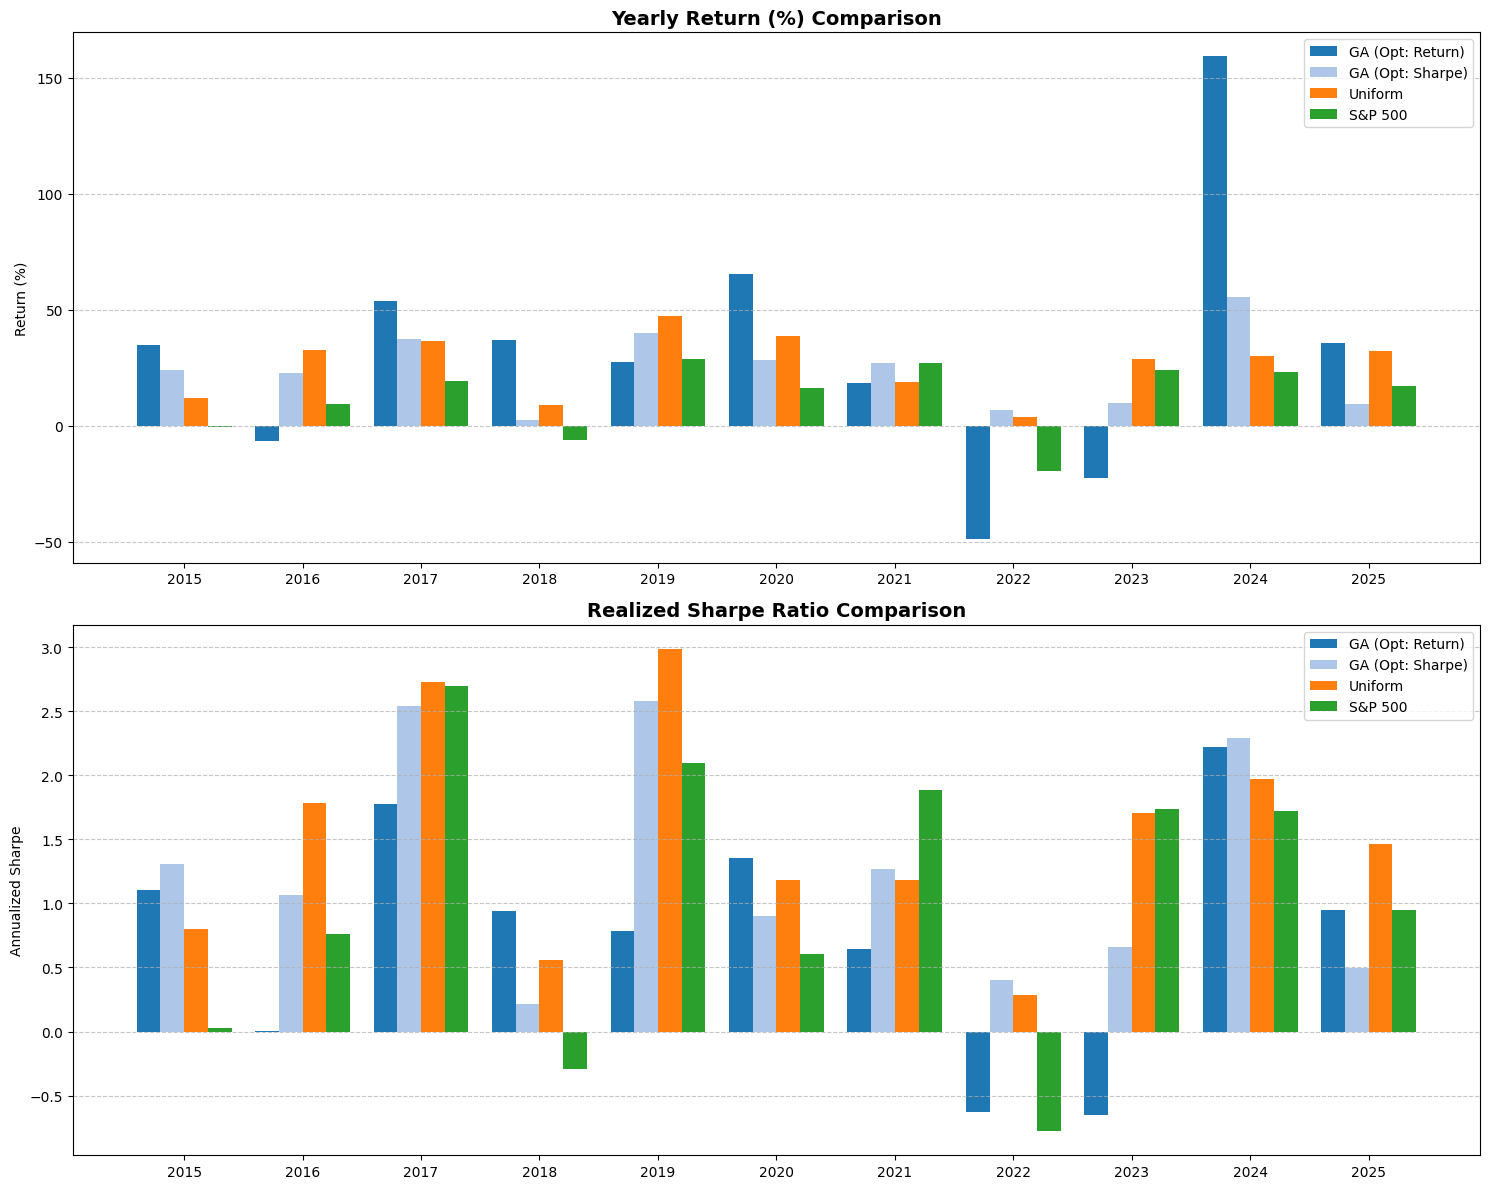

In [77]:
# 1. Pivot data for easier plotting
# We want to separate the GA results based on the objective used
df_plot = results_df.copy()
years = df_plot.index.get_level_values('year').unique()

# Extract GA data for each objective
ga_sharpe_obj = df_plot.xs('sharpe', level='objective')
ga_return_obj = df_plot.xs('return', level='objective')

# Extract Benchmarks (only need one row per year since they are the same)
benchmarks = ga_sharpe_obj[['uniform_return', 'sp500_return', 'uniform_realized_sharpe', 'sp500_sharpe']]

# 2. Setup Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
x = np.arange(len(years))
width = 0.2 

# --- SUBPLOT 1: ANNUAL RETURNS ---
ax1.bar(x - 1.5*width, (ga_return_obj['ga_return'] - 1)*100, width, label='GA (Opt: Return)', color='#1f77b4')
ax1.bar(x - 0.5*width, (ga_sharpe_obj['ga_return'] - 1)*100, width, label='GA (Opt: Sharpe)', color='#aec7e8')
ax1.bar(x + 0.5*width, (benchmarks['uniform_return'] - 1)*100, width, label='Uniform', color='#ff7f0e')
ax1.bar(x + 1.5*width, (benchmarks['sp500_return'] - 1)*100, width, label='S&P 500', color='#2ca02c')

ax1.set_title('Yearly Return (%) Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Return (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- SUBPLOT 2: REALIZED SHARPE ---
ax2.bar(x - 1.5*width, ga_return_obj['ga_realized_sharpe'], width, label='GA (Opt: Return)', color='#1f77b4')
ax2.bar(x - 0.5*width, ga_sharpe_obj['ga_realized_sharpe'], width, label='GA (Opt: Sharpe)', color='#aec7e8')
ax2.bar(x + 0.5*width, benchmarks['uniform_realized_sharpe'], width, label='Uniform', color='#ff7f0e')
ax2.bar(x + 1.5*width, benchmarks['sp500_sharpe'], width, label='S&P 500', color='#2ca02c')

ax2.set_title('Realized Sharpe Ratio Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Annualized Sharpe')
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [97]:
df_pivoted = results_df.unstack(level='objective')
bottom_line_df = pd.DataFrame({
    'ga_return_model_returns': df_pivoted[('ga_return', 'return')],
    'ga_sharpe_model_returns': df_pivoted[('ga_return', 'sharpe')],
    'uniform_returns': df_pivoted[('uniform_return', 'return')],
    'sp500_returns': df_pivoted[('sp500_return', 'return')],
    
    'ga_return_model_sharpe': df_pivoted[('ga_realized_sharpe', 'return')],
    'ga_sharpe_model_sharpe': df_pivoted[('ga_realized_sharpe', 'sharpe')],
    'uniform_sharpe': df_pivoted[('uniform_realized_sharpe', 'return')],
    'sp500_sharpe': df_pivoted[('sp500_sharpe', 'return')]
})

returns_summary_stats = pd.Series({
    'ga_model_return_opt_total_growth': bottom_line_df['ga_return_model_returns'].prod(),
    'ga_model_sharpe_opt_total_growth': bottom_line_df['ga_sharpe_model_returns'].prod(),
    'uniform_model_total_growth': bottom_line_df['uniform_returns'].prod(),
    'sp500_total_growth': bottom_line_df['sp500_returns'].prod(),
})

sharpe_summary_stats = pd.Series({
    'ga_model_return_opt_avg_sharpe': bottom_line_df['ga_return_model_sharpe'].mean(),
    'ga_model_sharpe_opt_avg_sharpe': bottom_line_df['ga_sharpe_model_sharpe'].mean(),
    'uniform_model_avg_sharpe': bottom_line_df['uniform_sharpe'].mean(),
    'sp500_avg_sharpe': bottom_line_df['sp500_sharpe'].mean(),
})

In [99]:
returns_summary_stats

ga_model_return_opt_total_growth     9.271977
ga_model_sharpe_opt_total_growth     9.737683
uniform_model_total_growth          12.358017
sp500_total_growth                   3.349478
dtype: float64

In [101]:
sharpe_summary_stats

ga_model_return_opt_avg_sharpe    0.772425
ga_model_sharpe_opt_avg_sharpe    1.247337
uniform_model_avg_sharpe          1.514021
sp500_avg_sharpe                  1.037969
dtype: float64